This notebook contains the code used to explore the following datasets
* ERA5
* TOOCAN
* TOOCAN Tb Expand
* TOOCAN Rain Flag

# Initialization

For this exercise, we use a random date from the dataset. I have decided to use July 4, 2019.

### Datasets

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter
import os

In [2]:
os.environ['PROJ_LIB'] = '/glade/u/apps/opt/miniforge/envs/npl-2026a/share/proj'

In [3]:
era5_dir = '/glade/work/addisus/GPM_TOOCAN_data/era5_select'
toocan_dir = '/glade/work/addisus/GPM_TOOCAN_data/gpm_select_toocan/'
toocan_temp_dir = '/glade/work/addisus/GPM_TOOCAN_data/gpm_select_TbExpand'
toocan_precip_dir = '/glade/work/addisus/GPM_TOOCAN_data/gpm_select_CnvStrNorainFlag'

In [4]:
def find_sample(date, dir):
    sample = ""
    for d in os.listdir(dir):
        if date in d:
            sample = d
            print(d)
            break
    return sample

In [5]:
date = '20190704'
sample_era5 = find_sample(date, era5_dir)
sample_toocan = find_sample(date, toocan_dir)
sample_toocan_temp = find_sample(date, toocan_temp_dir)
sample_toocan_precip = find_sample(date, toocan_precip_dir)

20190704.era5_select-toocan-subset_pm6hrsSearch.nc
20190704.gpm_select-toocan-subset.nc
20190704_TbExpand.nc
20190704.CnvStrNorainFlag.nc


In [6]:
era5_path = os.path.join(era5_dir, sample_era5)
toocan_path = os.path.join(toocan_dir, sample_toocan)
toocan_temp_path = os.path.join(toocan_temp_dir, sample_toocan_temp)
toocan_precip_path = os.path.join(toocan_precip_dir, sample_toocan_precip)

In [7]:
era5_ds = xr.open_dataset(era5_path)
toocan_ds = xr.open_dataset(toocan_path)
toocan_temp_ds = xr.open_dataset(toocan_temp_path)
toocan_precip_ds = xr.open_dataset(toocan_precip_path)

#### Cleaning

In [8]:
def clean_ds(ds):
    for var in ds.data_vars:
        if np.issubdtype(ds[var].dtype, np.number):
            ds[var] = ds[var].where(ds[var] > -9999)
    return ds

In [9]:
clean_ds(era5_ds)
clean_ds(toocan_ds)
clean_ds(toocan_temp_ds)
clean_ds(toocan_precip_ds)

<xarray.Dataset> Size: 1GB
Dimensions:  (nlon: 9000, nlat: 2001, nt: 18)
Dimensions without coordinates: nlon, nlat, nt
Data variables:
    lon      (nlon) float32 36kB -180.0 -180.0 -179.9 ... 179.9 179.9 180.0
    lat      (nlat) float32 8kB 40.0 39.96 39.92 39.88 ... -39.92 -39.96 -40.0
    time     (nt) float32 72B 1.0 2.0 2.5 4.0 5.0 ... 15.0 16.5 18.0 22.0 23.5
    flag     (nt, nlat, nlon) float32 1GB nan nan nan nan ... nan nan nan nan
Attributes:
    dataset:  GPM convective, Stratiform and Norain Type mapped onto TOOCAN g...
    source:   TOOCAN segmented images - Gridded data 0.04 (Thomas Fiolleau <t...

### DCS Number Extraction

In [10]:
def get_dcs_dict(toocan_ds):
    """Return list of (ti, si, dcs_number), de-duplicated and sorted."""
    # ti = time index
    # si = system index
    
    dcs  = toocan_ds["DCS_number"].values
    idx  = list(zip(*np.argwhere(dcs > 0).T))
    seen, unique = {}, []
    for ti, si in idx:
        d = int(dcs[ti, si])
        if d not in seen:
            seen[d] = (ti, si)
            lc_lon = float(toocan_ds["lc_lon"].values[ti, si])
            lc_lat = float(toocan_ds["lc_lat"].values[ti, si])
            unique.append((d, ti, si, (lc_lon, lc_lat)))
    unique.sort(key=lambda x: x[0])
    dcs_dict = {int(dcs): (int(ti), int(si), (lc_lon, lc_lat)) for dcs, ti, si, (lc_lon, lc_lat) in unique}
    
    return dcs_dict


In [11]:
dcs_dict = get_dcs_dict(toocan_ds)

dcs_dict

{3349899: (44, 0, (9.829999923706055, 7.050000190734863)),
 3349905: (44, 1, (6.980000019073486, 7.599999904632568)),
 3349907: (44, 2, (8.970000267028809, 8.520000457763672)),
 3349982: (47, 0, (-11.5600004196167, 12.0600004196167)),
 3350066: (44, 3, (10.470000267028809, 10.619999885559082)),
 3350199: (21, 0, (-1.25, 9.359999656677246)),
 3350207: (44, 4, (7.429999828338623, 5.659999847412109)),
 3350604: (47, 1, (-13.0, 11.680000305175781)),
 3351152: (4, 0, (-46.939998626708984, 8.619999885559082)),
 3351528: (24, 0, (-6.840000152587891, -38.40999984741211)),
 3351550: (44, 5, (8.079999923706055, 4.599999904632568)),
 3351924: (24, 1, (-25.790000915527344, 6.949999809265137)),
 3354748: (15, 0, (51.09000015258789, -7.329999923706055)),
 3354799: (47, 2, (-32.81999969482422, -34.709999084472656)),
 3354801: (47, 3, (-33.869998931884766, -33.25)),
 3355471: (47, 4, (-31.040000915527344, -34.81999969482422)),
 3356198: (47, 5, (-31.979999542236328, -30.739999771118164)),
 3356974: (2

# TOOCAN

## Mean Vertical Profiles

First we will look at mean vertical profiles from the TOOCAN dataset.

### Shortwave and Longwave Heating Profiles

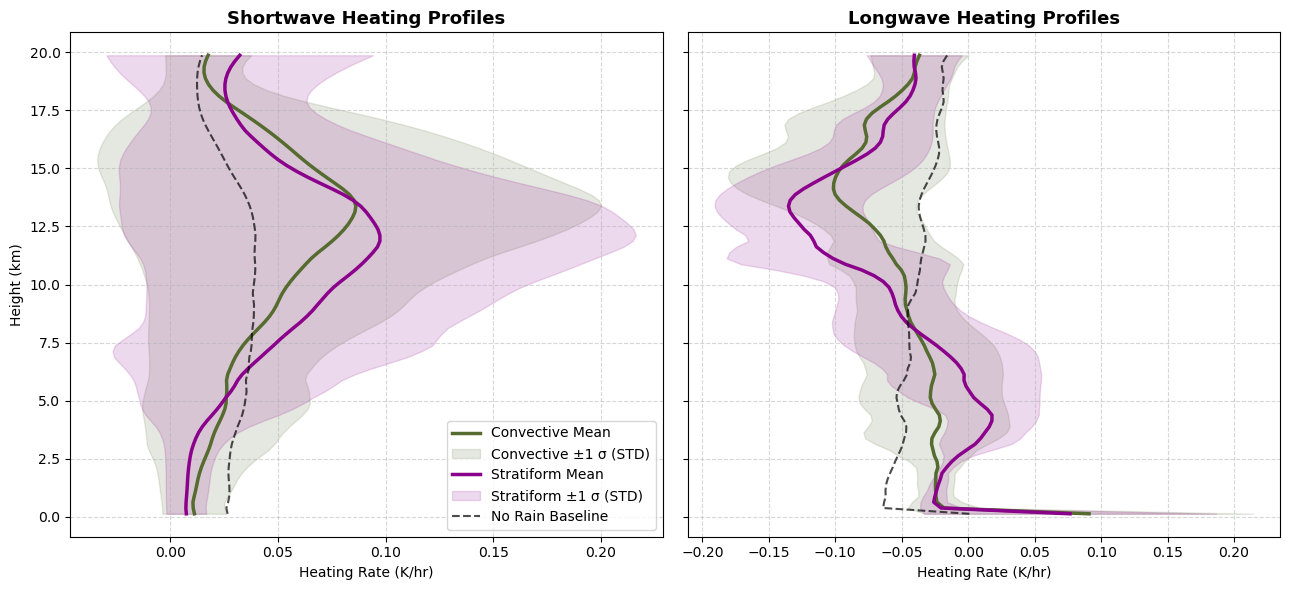

In [12]:
sw = toocan_ds['swheating']
lw = toocan_ds['lwheating']

# calculate mean and std for sw heating
mean_sw = sw.mean(dim=['nt', 'nsysmax'])
std_sw = sw.std(dim=['nt', 'nsysmax'])

# calculate mean and std for lw heating
mean_lw = lw.mean(dim=['nt', 'nsysmax'])
std_lw = lw.std(dim=['nt', 'nsysmax'])

# initialize plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
height = toocan_ds['nlvl']

# Shortwave Heating Profile
# convective
ax1.plot(mean_sw.isel(nc1=0), height, label='Convective Mean', color='darkolivegreen', linewidth=2.5)
ax1.fill_betweenx(height, mean_sw.isel(nc1=0) - std_sw.isel(nc1=0), mean_sw.isel(nc1=0) + std_sw.isel(nc1=0), 
                  color='darkolivegreen', alpha=0.15, label='Convective ±1 σ (STD)')

# stratiform
ax1.plot(mean_sw.isel(nc1=1), height, label='Stratiform Mean', color='darkmagenta', linewidth=2.5)
ax1.fill_betweenx(height, mean_sw.isel(nc1=1) - std_sw.isel(nc1=1), mean_sw.isel(nc1=1) + std_sw.isel(nc1=1), 
                  color='darkmagenta', alpha=0.15, label='Stratiform ±1 σ (STD)')
# no rain
ax1.plot(mean_sw.isel(nc1=2), height, label='No Rain Baseline', color='black', linestyle='--', linewidth=1.5, alpha=0.7)

ax1.set_title('Shortwave Heating Profiles', fontsize=13, fontweight='bold')
ax1.set_xlabel('Heating Rate (K/hr)')
ax1.set_ylabel('Height (km)')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=10, loc='best')

# Longwave Heating
# convective
ax2.plot(mean_lw.isel(nc1=0), height, color='darkolivegreen', linewidth=2.5)
ax2.fill_betweenx(height, mean_lw.isel(nc1=0) - std_lw.isel(nc1=0), mean_lw.isel(nc1=0) + std_lw.isel(nc1=0), color='darkolivegreen', alpha=0.15)

# stratiform
ax2.plot(mean_lw.isel(nc1=1), height, color='darkmagenta', linewidth=2.5)
ax2.fill_betweenx(height, mean_lw.isel(nc1=1) - std_lw.isel(nc1=1), mean_lw.isel(nc1=1) + std_lw.isel(nc1=1), color='darkmagenta', alpha=0.15)
# no rain
ax2.plot(mean_lw.isel(nc1=2), height, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

ax2.set_title('Longwave Heating Profiles', fontsize=13, fontweight='bold')
ax2.set_xlabel('Heating Rate (K/hr)')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("toocan_era5_plots/sw_lw_heating_profiles.png", transparent=True)
plt.show()

### Latent Heating Profile

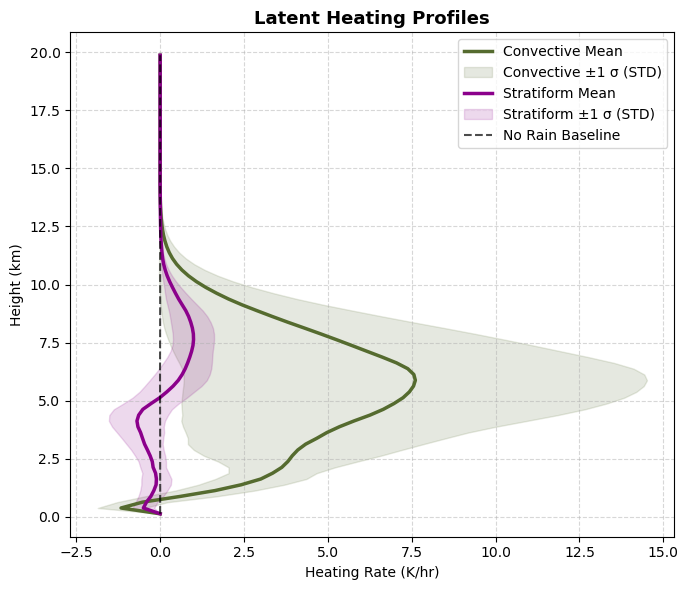

In [13]:
lat = toocan_ds['latheating']

# calculate mean and std
mean_lat = lat.mean(dim=['nt', 'nsysmax'])
std_lat = lat.std(dim=['nt', 'nsysmax'])

# intialize plot
fig, ax = plt.subplots(figsize=(7, 6))
height = toocan_ds['nlvl']

# convective
ax.plot(mean_lat.isel(nc1=0), height, label='Convective Mean', color='darkolivegreen', linewidth=2.5)
ax.fill_betweenx(height, mean_lat.isel(nc1=0) - std_lat.isel(nc1=0), mean_lat.isel(nc1=0) + std_lat.isel(nc1=0), 
                 color='darkolivegreen', alpha=0.15, label='Convective ±1 σ (STD)')

# stratiform
ax.plot(mean_lat.isel(nc1=1), height, label='Stratiform Mean', color='darkmagenta', linewidth=2.5)
ax.fill_betweenx(height, mean_lat.isel(nc1=1) - std_lat.isel(nc1=1), mean_lat.isel(nc1=1) + std_lat.isel(nc1=1), 
                 color='darkmagenta', alpha=0.15, label='Stratiform ±1 σ (STD)')

# no rain
ax.plot(mean_lat.isel(nc1=2), height, label='No Rain Baseline', color='black', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_title('Latent Heating Profiles', fontsize=13, fontweight='bold')
ax.set_xlabel('Heating Rate (K/hr)')
ax.set_ylabel('Height (km)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.savefig("toocan_era5_plots/lat_heating_profile.png", transparent=True)
plt.show()

### Eddy Profiles

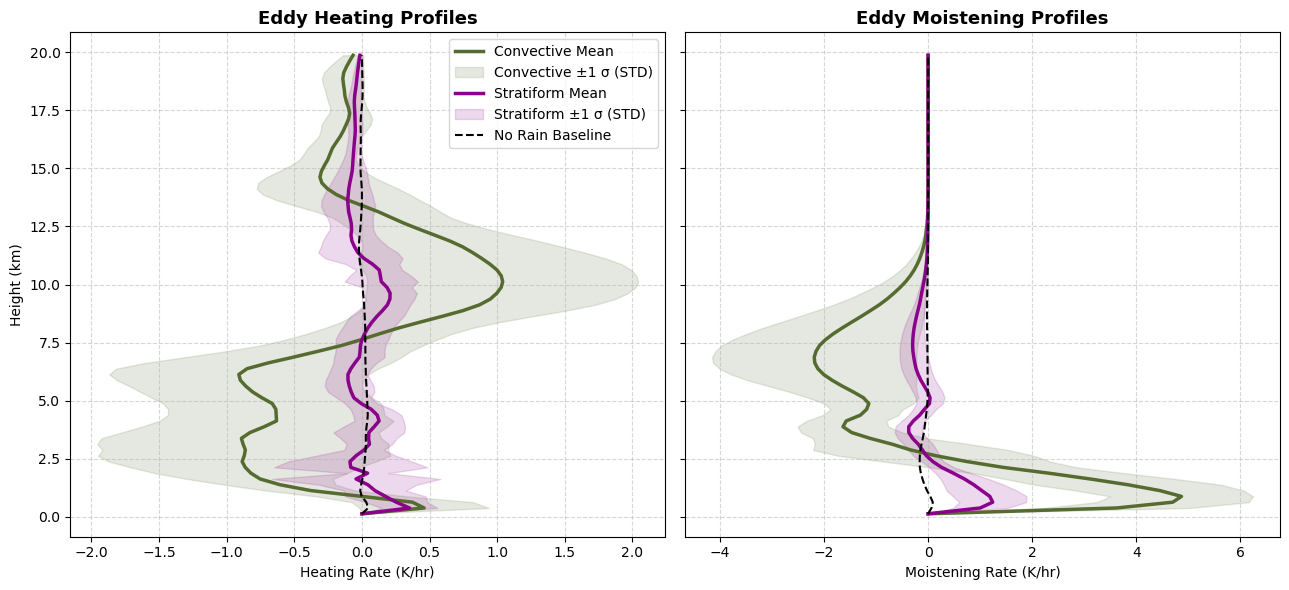

In [14]:
eddy_heat = toocan_ds['eddyheating']
eddy_moist = toocan_ds['eddymoistening']

# calculate mean and std eddy_heat
mean_eddy_heat = eddy_heat.mean(dim=['nt', 'nsysmax'])
std_eddy_heat = eddy_heat.std(dim=['nt', 'nsysmax'])

# calculate mean and std eddy_moist
mean_eddy_moist = eddy_moist.mean(dim=['nt', 'nsysmax'])
std_eddy_moist = eddy_moist.std(dim=['nt', 'nsysmax'])

# initialize plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
height = toocan_ds['nlvl']

# Eddy Heating
# convective
ax1.plot(mean_eddy_heat.isel(nc1=0), height, label='Convective Mean', color='darkolivegreen', linewidth=2.5)
ax1.fill_betweenx(height, mean_eddy_heat.isel(nc1=0) - std_eddy_heat.isel(nc1=0), mean_eddy_heat.isel(nc1=0) + std_eddy_heat.isel(nc1=0), 
                  color='darkolivegreen', alpha=0.15, label='Convective ±1 σ (STD)')

# stratiform
ax1.plot(mean_eddy_heat.isel(nc1=1), height, label='Stratiform Mean', color='darkmagenta', linewidth=2.5)
ax1.fill_betweenx(height, mean_eddy_heat.isel(nc1=1) - std_eddy_heat.isel(nc1=1), mean_eddy_heat.isel(nc1=1) + std_eddy_heat.isel(nc1=1), 
                  color='darkmagenta', alpha=0.15, label='Stratiform ±1 σ (STD)')

# no rain
ax1.plot(mean_eddy_heat.isel(nc1=2), height, label='No Rain Baseline', color='black', linestyle='--', linewidth=1.5, alpha=1.0)

ax1.set_title('Eddy Heating Profiles', fontsize=13, fontweight='bold')
ax1.set_xlabel('Heating Rate (K/hr)')
ax1.set_ylabel('Height (km)')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=10, loc='best')

# Eddy Moistening
# convective
ax2.plot(mean_eddy_moist.isel(nc1=0), height, color='darkolivegreen', linewidth=2.5)
ax2.fill_betweenx(height, mean_eddy_moist.isel(nc1=0) - std_eddy_moist.isel(nc1=0), mean_eddy_moist.isel(nc1=0) + std_eddy_moist.isel(nc1=0), color='darkolivegreen', alpha=0.15)

# stratiform
ax2.plot(mean_eddy_moist.isel(nc1=1), height, color='darkmagenta', linewidth=2.5)
ax2.fill_betweenx(height, mean_eddy_moist.isel(nc1=1) - std_eddy_moist.isel(nc1=1), mean_eddy_moist.isel(nc1=1) + std_eddy_moist.isel(nc1=1), color='darkmagenta', alpha=0.15)

# no rain
ax2.plot(mean_eddy_moist.isel(nc1=2), height, color='black', linestyle='--', linewidth=1.5, alpha=1.0)

ax2.set_title('Eddy Moistening Profiles', fontsize=13, fontweight='bold')
ax2.set_xlabel('Moistening Rate (K/hr)')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("toocan_era5_plots/eddy_profiles.png", transparent=True)
plt.show()

# TOOCAN Tb

We will now look at the spatial brightness temperature plots per DCS number.

In [15]:
def plot_tb(target_system):
    ti, si, center = dcs_dict[target_system]

    dcs_spatial = toocan_temp_ds["DCS_number"].isel(nt=ti).load().values
    tb_spatial  = toocan_temp_ds["Tb"].isel(nt=ti).load().values
    lat_arr     = toocan_temp_ds["lat"].values
    lon_arr     = toocan_temp_ds["lon"].values

    sys_mask  = (dcs_spatial == target_system)
    sys_rows, sys_cols = np.where(sys_mask)
    
    EXTRA_MARGIN = 5
    r0 = max(sys_rows.min() - EXTRA_MARGIN, 0)
    r1 = min(sys_rows.max() + EXTRA_MARGIN + 1, len(lat_arr))
    c0 = max(sys_cols.min() - EXTRA_MARGIN, 0)
    c1 = min(sys_cols.max() + EXTRA_MARGIN + 1, len(lon_arr))

    tb_sub   = tb_spatial[r0:r1, c0:c1]
    mask_sub = sys_mask[r0:r1, c0:c1]
    lat_sub  = lat_arr[r0:r1]
    lon_sub  = lon_arr[c0:c1]

    
    lc_lon, lc_lat = center
    time_h = float(toocan_ds["time"].values[ti])


    fig, ax = plt.subplots(figsize=(7, 6))
    
    # 2. Build the 2D coordinate meshgrids from your slices
    LON2D, LAT2D = np.meshgrid(lon_sub, lat_sub)
    
    # 3. Mask out the background pixels so you ONLY see the storm shape
    # We replace any pixel NOT matching the mask with NaN
    tb_masked = np.where(mask_sub, tb_sub, np.nan)
    
    # 4. Plot using pcolormesh bound to the real Lat/Lon meshgrid
    # Using 'RdYlBu_r' makes convective cores dark blue/purple (cold)
    im = ax.pcolormesh(LON2D, LAT2D, tb_sub, cmap='RdYlBu_r', 
                       vmin=180, vmax=310, shading='nearest')
    
    ax.contour(LON2D, LAT2D, mask_sub, levels=[0.5], colors='black', linewidths=1.5, zorder=5)

    # 5. Add a clean colorbar
    plt.colorbar(im, ax=ax, label="Brightness Temperature (K)", 
                 fraction=0.046, pad=0.04)
    
    # 6. Plot the official TOOCAN center point as a white star
    ax.plot(lc_lon, lc_lat, marker="*", color="purple", markersize=14, 
            markeredgecolor="black", markeredgewidth=1.5, label="Center", zorder=10)
    
    # 7. Labels and presentation
    ax.set_title(f"Brightness Temperature: DCS #{int(target_system)} at {time_h:.1f}h UTC\n"
                 f"Center: ({lc_lon:.1f}°E, {lc_lat:.1f}°N)", fontsize=10, fontweight='bold')
    ax.set_xlabel("Longitude [°E]", fontsize=9)
    ax.set_ylabel("Latitude [°N]", fontsize=9)
    ax.legend(loc="upper right")
    
    # Clean render and close the active plot memory
    plt.savefig(f"tb_plot_{int(target_system)}.png", transparent=True)
    plt.show()
    plt.close()

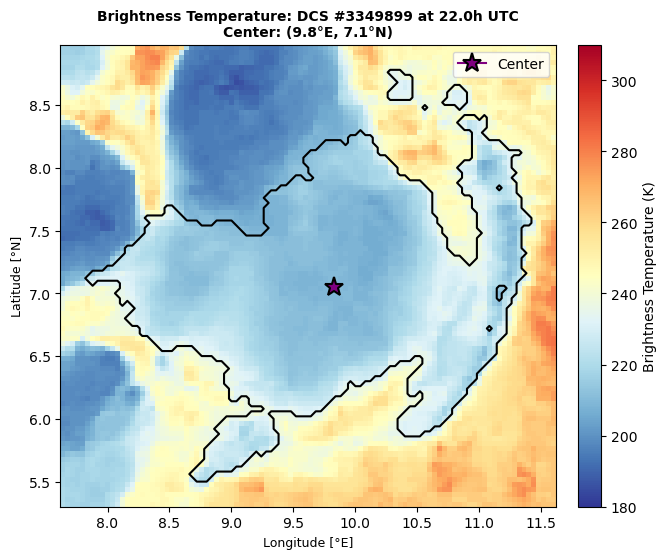

In [16]:
# example run

plot_tb(3349899)

# TOOCAN Rain Flag

We can also look at spatial plots with rain flag (convective, non convective, no rain) info.

In [17]:
def plot_precip_flags(target_system):
    # 1. Look up the tracking dataset time index (ti) and system index (si)
    ti, si, center = dcs_dict[target_system]
    lc_lon, lc_lat = center

    # 2. Get the real-world hour value for this step from the temperature dataset
    target_time_hour = float(toocan_temp_ds["time"].isel(nt=ti).values)

    # 3. Find the matching time index in the precipitation dataset
    precip_hours = toocan_precip_ds["time"].values
    precip_ti = np.argmin(np.abs(precip_hours - target_time_hour))
    
    # Safety Check: Check if a satellite overpass actually happened near this hour
    if np.abs(precip_hours[precip_ti] - target_time_hour) > 0.3:
        print(f"Skipping: GPM satellite was not over this region at Hour {target_time_hour:.1f} ")
        return

    # 4. Load spatial arrays
    dcs_spatial = toocan_temp_ds["DCS_number"].isel(nt=ti).load().values
    precip_spatial = toocan_precip_ds["flag"].isel(nt=precip_ti).load().values
    
    lat_arr = toocan_temp_ds["lat"].values
    lon_arr = toocan_temp_ds["lon"].values

    # 5. Create individual masks
    sys_mask = (dcs_spatial == target_system)               # The tracked cloud shield
    precip_mask = ~np.isnan(precip_spatial)                 # Anywhere GPM actually has flags (1, 2, or 3)
    
    # CRITICAL CHANGE: Combine masks so the bounding box looks at BOTH regions
    # It finds the rows/cols where the storm is tracked AND where the radar swath overlaps it
    combined_mask = sys_mask & precip_mask
    sys_rows, sys_cols = np.where(combined_mask)
    
    # Fallback: If they don't overlap at all, default to just the tracked system boundary
    if len(sys_rows) == 0:
        sys_rows, sys_cols = np.where(sys_mask)
        if len(sys_rows) == 0:
            print(f"System #{target_system} has no valid spatial footprint.")
            return
    
    # Define bounding box with a margin
    EXTRA_MARGIN = 50  
    r0 = max(sys_rows.min() - EXTRA_MARGIN, 0)
    r1 = min(sys_rows.max() + EXTRA_MARGIN + 1, len(lat_arr))
    c0 = max(sys_cols.min() - EXTRA_MARGIN, 0)
    c1 = min(sys_cols.max() + EXTRA_MARGIN + 1, len(lon_arr))

    # Slice out our sub-grids
    precip_sub = precip_spatial[r0:r1, c0:c1]
    mask_sub   = sys_mask[r0:r1, c0:c1]
    lat_sub    = lat_arr[r0:r1]
    lon_sub    = lon_arr[c0:c1]

    # Build the 2D coordinate meshgrids
    LON2D, LAT2D = np.meshgrid(lon_sub, lat_sub)
    
    # Define discrete categorical colormap for flags 1, 2, 3
    cmap = mcolors.ListedColormap(['darkmagenta', 'darkolivegreen', 'lightgray'])
    bounds = [0.5, 1.5, 2.5, 3.5]  
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    fig, ax = plt.subplots(figsize=(7, 6))
    
    # Plot the full unmasked background so you see the complete flag profile
    im = ax.pcolormesh(LON2D, LAT2D, precip_sub, cmap=cmap, norm=norm, shading='nearest')

    ax.contour(LON2D, LAT2D, mask_sub, levels=[0.5], colors='black', linewidths=1.5, zorder=5)

    # Dynamic categorical colorbar
    cbar = plt.colorbar(im, ax=ax, ticks=[1, 2, 3], fraction=0.046, pad=0.04)
    cbar.set_ticklabels(['Convective', 'Non-Convective', 'No Rain'], va="center")
    cbar.ax.tick_params(labelsize=9, rotation=90)
    
    # Official TOOCAN center point as a star
    ax.plot(lc_lon, lc_lat, marker="*", color="red", markersize=14, 
            markeredgecolor="black", markeredgewidth=1.5, label="Storm Center", zorder=10)
    
    # Labels and presentation
    ax.set_title(f"Precipitation Flags: DCS #{int(target_system)} at {target_time_hour:.1f}h UTC\n"
                 f"Center: ({lc_lon:.1f}°E, {lc_lat:.1f}°N)", fontsize=10, fontweight='bold')
    ax.set_xlabel("Longitude [°E]", fontsize=9)
    ax.set_ylabel("Latitude [°N]", fontsize=9)
    ax.legend(loc="upper right")
    
    plt.tight_layout()
    plt.savefig(f"precip_flag_{int(target_system)}.png", transparent=True)
    plt.show()
    plt.close()

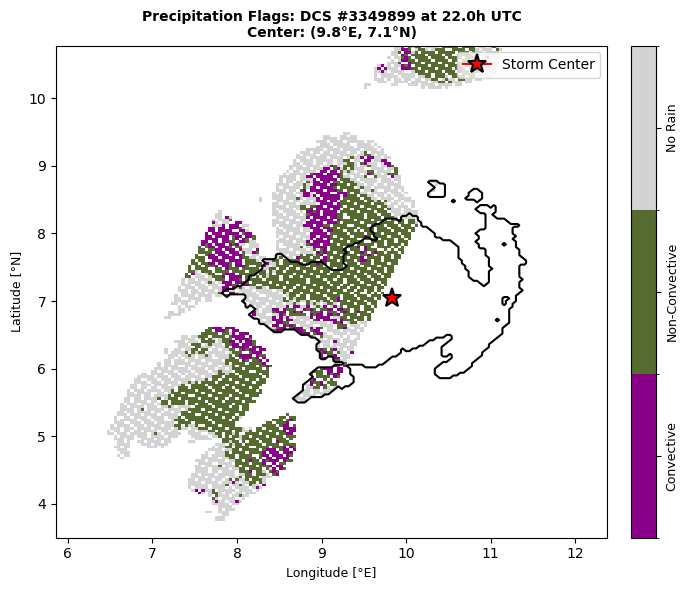

In [18]:
# example run

plot_precip_flags(3349899)

# ERA5

## Helper

In [19]:
def apply_clean_pressure_axis(ax):
    """Helper function to format the vertical pressure axis cleanly."""
    ax.set_yscale('log')
    ax.set_ylim(1000, 40)  # Standard atmospheric boundaries (Surface to Tropopause)
    ax.set_ylabel('Pressure (hPa)', fontsize=12)
    
    # Force matplotlib to show raw numbers instead of powers of 10 (10^2, 10^3)
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_minor_formatter(ScalarFormatter())    # Ensure labels don't get bunched up or drop off in log scale
    ax.tick_params(axis='y', which='both', labelsize=10)
    ax.grid(True, which="both", linestyle="--", alpha=0.6)

## Temperature

In [20]:
def generate_temperature_plot(storm_ds, target_system, storm_info):
    """Generates a standalone Temperature profile figure."""
    fig, ax = plt.subplots(figsize=(7, 6))
    mean_profile = storm_ds.isel(nc2=0, nc1=0)
    
    ax.plot(mean_profile['tprof'], mean_profile['plev'], marker='o', color='tab:purple', linewidth=2)
    ax.set_xlabel('Temperature (K)', fontsize=12)
    ax.set_title(f"Temperature Profile (tprof): {storm_info}", fontsize=14, fontweight='bold')
    apply_clean_pressure_axis(ax)
    
    plt.tight_layout()
    plt.savefig(f"temp_profile_{int(target_system)}.png", transparent=True)
    plt.show()

## Wind

In [21]:
def generate_wind_plot(storm_ds, target_system, storm_info):
    """Generates a standalone Wind Velocity profiles figure."""
    fig, ax = plt.subplots(figsize=(7, 6))
    mean_wind = storm_ds.isel(nc2=0)
    plev = storm_ds['plev'].isel(nc2=0, nc1=0)
    
    ax.plot(mean_wind['uprof'], plev, marker='s', color='tab:blue', label='U (Eastward)', linewidth=2)
    ax.plot(mean_wind['vprof'], plev, marker='^', color='tab:green', label='V (Northward)', linewidth=2)
    ax.set_xlabel('Wind Speed ($\mathdefault{m/s}$)', fontsize=12)
    ax.set_title(f"Wind Velocity Profile: {storm_info}", fontsize=14, fontweight='bold')
    ax.legend(frameon=True)
    apply_clean_pressure_axis(ax)
    
    plt.tight_layout()
    plt.savefig(f"wind_profile_{int(target_system)}.png", transparent=True)
    plt.show()

## Humidity

In [22]:
def generate_humidity_plot(storm_ds, target_system, storm_info):
    """Generates a standalone Specific Humidity (qprof) profile figure."""
    fig, ax = plt.subplots(figsize=(7, 6))
    mean_profile = storm_ds.isel(nc2=0, nc1=0)
    
    ax.plot(mean_profile['qprof'], mean_profile['plev'], marker='d', color='tab:purple', linewidth=2)
    ax.set_xlabel('Specific Humidity (g/kg)', fontsize=12)
    ax.set_title(f"Humidity Profile (qprof): {storm_info}", fontsize=14, fontweight='bold')
    apply_clean_pressure_axis(ax)
    
    plt.tight_layout()
    plt.savefig(f"humidity_profile_{int(target_system)}.png", transparent=True)
    plt.show()

## CAPE

In [23]:
def generate_cape_plot(storm_ds, target_system, storm_info):
    """Generates a standalone CAPE percentile distribution bar chart."""
    fig, ax = plt.subplots(figsize=(7, 5))
    cape_values = storm_ds['CAPE'].isel(nc2=0).values  
    percentile_labels = ['Mean', '25th Pct', '50th Pct', '75th Pct']
    
    ax.bar(percentile_labels, cape_values, color='darkolivegreen', edgecolor='darkolivegreen', alpha=0.8, width=0.5)
    ax.set_ylabel('CAPE ($\mathdefault{J/kg}$)', fontsize=12)
    ax.set_title(f"CAPE Profiles: {storm_info}", fontsize=14, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(f"cape_profile_{int(target_system)}.png", transparent=True)
    plt.show()

## Full Analysis

In [24]:
def plot_storm_analysis(target_system, dcs_dict, era5_ds):
    """Master orchestrator to isolate data and call each standalone plot function sequentially."""
    nt_idx = dcs_dict[target_system][0]
    nsys_idx = dcs_dict[target_system][1]
    lc_lon, lc_lat = dcs_dict[target_system][2]
    time_h = float(toocan_ds["time"].values[nt_idx])

    # Isolate data once
    storm_ds = era5_ds.isel(nt=nt_idx, nsysmax=nsys_idx)
    
    # Fire off individual window renderings
    storm_info = f"DCS #{int(target_system)} at {time_h:.1f}h UTC\nCenter: ({lc_lon:.1f}°E, {lc_lat:.1f}°N)"
    generate_temperature_plot(storm_ds, target_system, storm_info)
    generate_wind_plot(storm_ds, target_system, storm_info)
    generate_humidity_plot(storm_ds, target_system, storm_info)
    generate_cape_plot(storm_ds, target_system, storm_info)

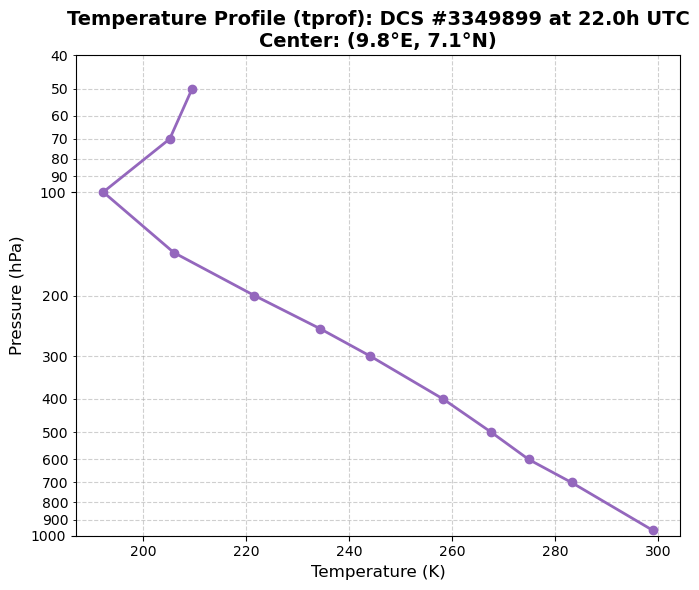

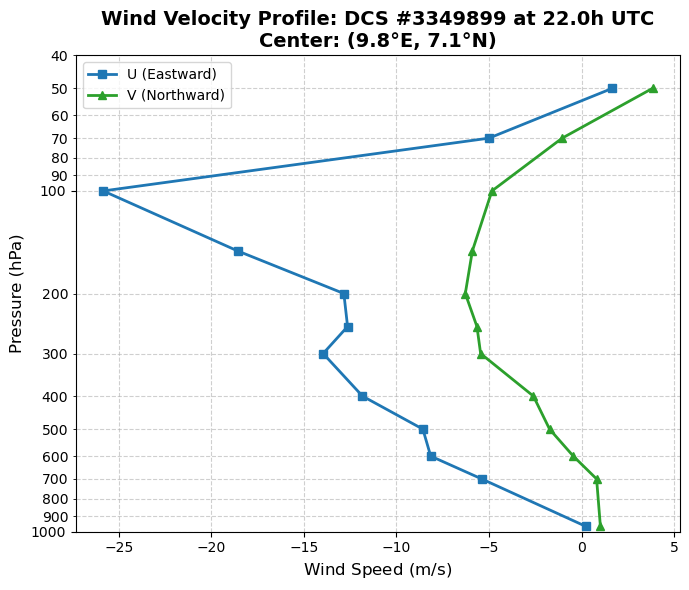

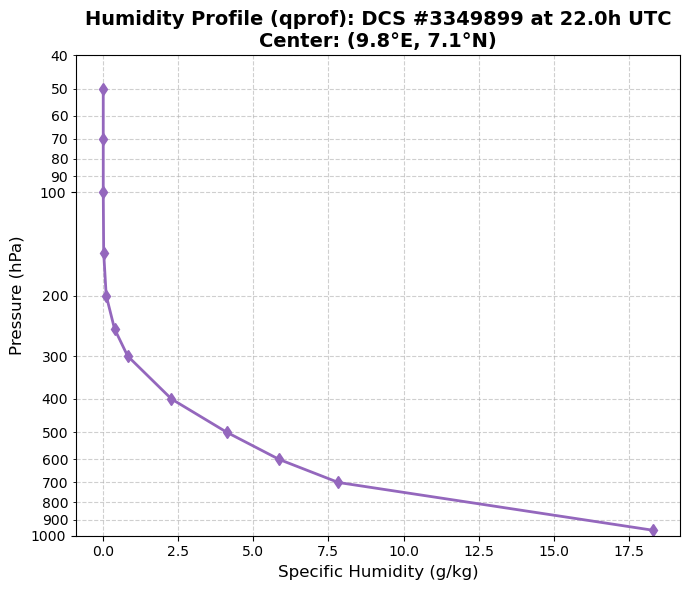

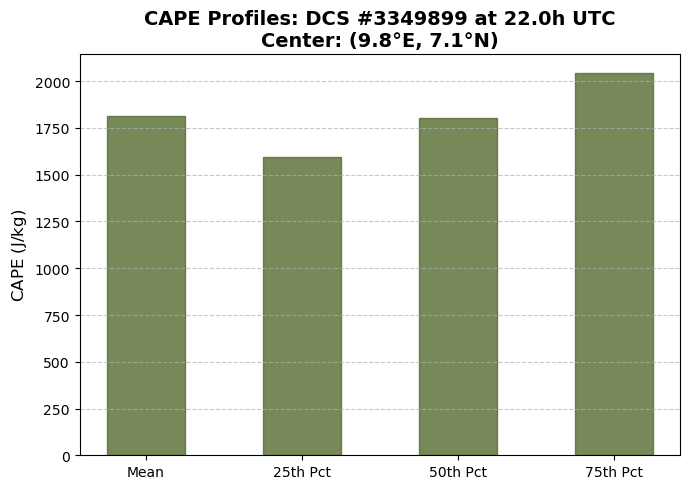

In [25]:
# sample run

plot_storm_analysis(3349899, dcs_dict, era5_ds)

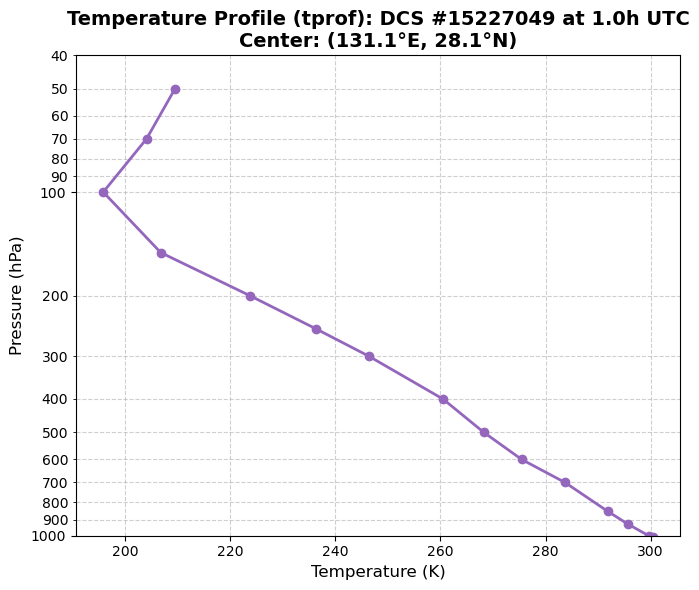

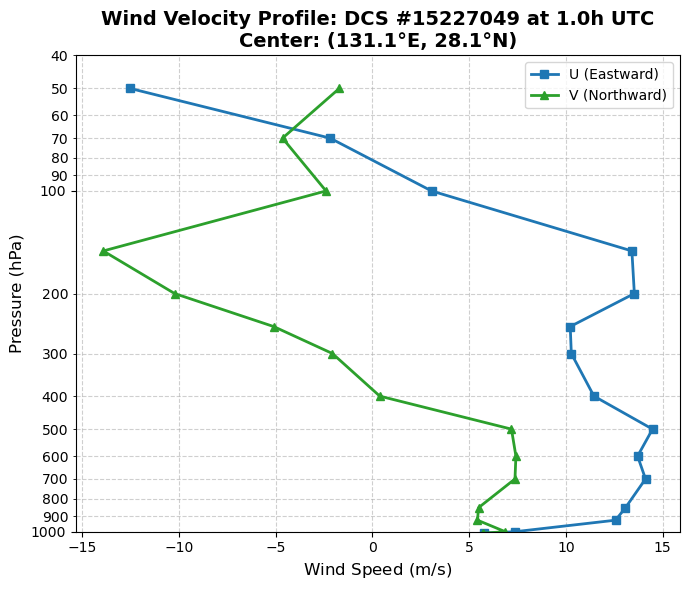

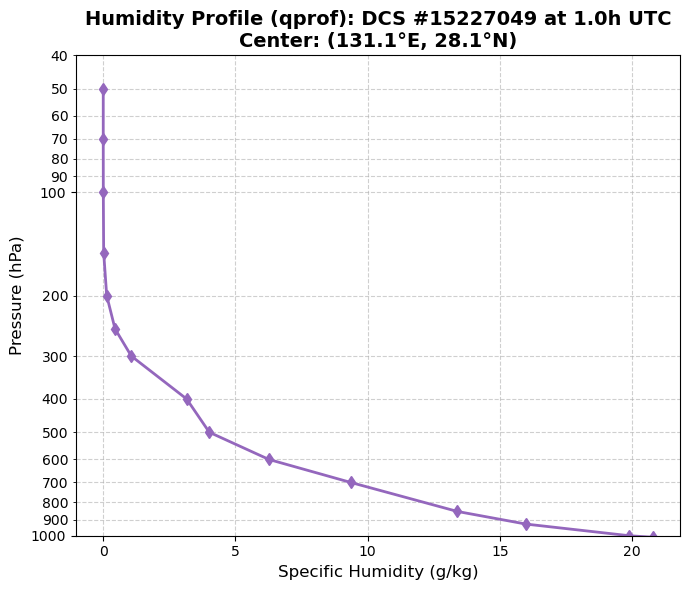

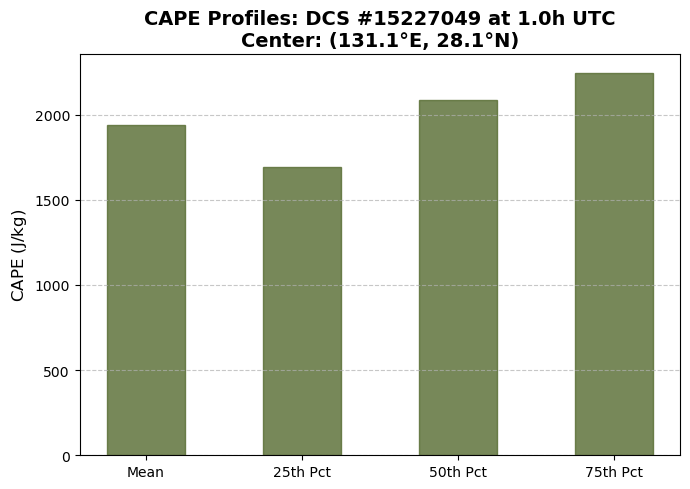

In [26]:
plot_storm_analysis(15227049, dcs_dict, era5_ds)

## ERA5 + TOOCAN

Positive CAPE != Convection

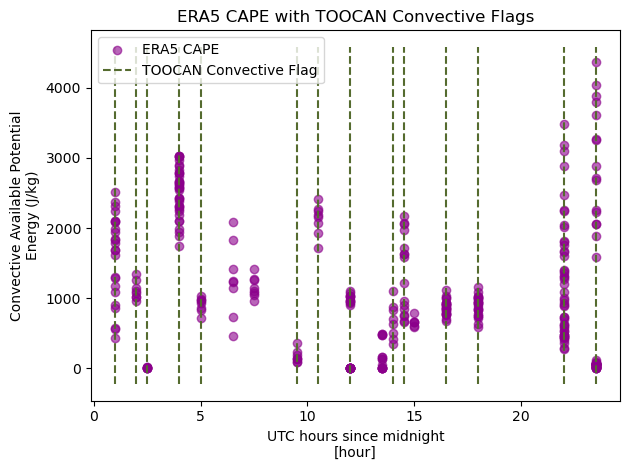

In [27]:
# 1. Determine if ANY rain exists at each time step (Collapses spatial dims)
# .any(dim=['nlat', 'nlon']) results in a 1D array of True/False values for each time step
rain_exists_per_step = (toocan_precip_ds["flag"] == 1).any(dim=['nlat', 'nlon'])

# 2. Filter the time coordinates based on that boolean array
# This gives you a 1D list of UNIQUE time steps where rain occurred
flag_times = toocan_precip_ds["time"].where(rain_exists_per_step, drop=True).values

# 3. Plot ERA5 CAPE
ax = plt.gca()
era5_ds.where(era5_ds != -9999).plot.scatter(
    x="time", y="CAPE", color="darkmagenta", label="ERA5 CAPE", alpha=0.6, ax=ax
)

# 4. Plot unique lines
ymin, ymax = ax.get_ylim()
ax.vlines(x=flag_times, ymin=ymin, ymax=ymax, color="darkolivegreen", 
          alpha=1, linestyle="--", label="TOOCAN Convective Flag")

ax.set_title("ERA5 CAPE with TOOCAN Convective Flags")
plt.legend()
plt.tight_layout()
plt.savefig("toocan_era5_plots/ERA5_CAPE_with_TOOCAN_Flags.png", transparent = True, dpi=300)
plt.show()